In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
PROJECT_ROOT = Path("..")

CLEAN_DATA = PROJECT_ROOT / "data" / "clean"
FIGURES = PROJECT_ROOT / "figures"

In [3]:
file_path = CLEAN_DATA / "spotify_final.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (8775, 16)


,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min,release_year
0,6pymOcrCnMuCWdgGVTvUgP,3,57,61,False,Britney Spears,80.0,17755451.0,pop,325wcm5wMnlfjmKZ8PXIIn,The Singles Collection,2009-11-09,58,compilation,3.55,2009
1,2lWc1iJlz2NVcStV5fbtPG,Clouds,1,67,False,BUNT.,69.0,293734.0,stutter house,2ArRQNLxf9t0O0gvmG5Vsj,Clouds,2023-01-13,1,single,2.65,2023
2,1msEuwSBneBKpVCZQcFTsU,Forever & Always (Taylor’s Version),11,63,False,Taylor Swift,100.0,145396321.0,NaN,4hDok0OAJd57SGIT8xuWJH,Fearless (Taylor's Version),2021-04-09,26,album,3.76,2021
3,7bcy34fBT2ap1L4bfPsl9q,I Didn't Change My Number,2,72,True,Billie Eilish,90.0,118692183.0,NaN,0JGOiO34nwfUdDrD612dOp,Happier Than Ever,2021-07-30,16,album,2.64,2021
4,0GLfodYacy3BJE7AI3A8en,Man Down,7,57,False,Rihanna,90.0,68997177.0,NaN,5QG3tjE5L9F6O2vCAPph38,Loud,2010-01-01,13,album,4.45,2010


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 8775 entries, 0 to 8774
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_id            8775 non-null   str    
 1   track_name          8775 non-null   str    
 2   track_number        8775 non-null   int64  
 3   track_popularity    8775 non-null   int64  
 4   explicit            8775 non-null   bool   
 5   artist_name         8773 non-null   str    
 6   artist_popularity   8772 non-null   float64
 7   artist_followers    8772 non-null   float64
 8   artist_genres       4283 non-null   str    
 9   album_id            8775 non-null   str    
 10  album_name          8775 non-null   str    
 11  album_release_date  8775 non-null   str    
 12  album_total_tracks  8775 non-null   int64  
 13  album_type          8775 non-null   str    
 14  track_duration_min  8775 non-null   float64
 15  release_year        8775 non-null   int64  
dtypes: bool(1), float

In [5]:
print("Duplicate rows:", df.duplicated().sum())
print("\nMissing values:")
print(df.isna().sum())

Duplicate rows: 0

Missing values:
track_id                 0
track_name               0
track_number             0
track_popularity         0
explicit                 0
artist_name              2
artist_popularity        3
artist_followers         3
artist_genres         4492
album_id                 0
album_name               0
album_release_date       0
album_total_tracks       0
album_type               0
track_duration_min       0
release_year             0
dtype: int64


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8775 entries, 0 to 8774
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_id            8775 non-null   str    
 1   track_name          8775 non-null   str    
 2   track_number        8775 non-null   int64  
 3   track_popularity    8775 non-null   int64  
 4   explicit            8775 non-null   bool   
 5   artist_name         8773 non-null   str    
 6   artist_popularity   8772 non-null   float64
 7   artist_followers    8772 non-null   float64
 8   artist_genres       4283 non-null   str    
 9   album_id            8775 non-null   str    
 10  album_name          8775 non-null   str    
 11  album_release_date  8775 non-null   str    
 12  album_total_tracks  8775 non-null   int64  
 13  album_type          8775 non-null   str    
 14  track_duration_min  8775 non-null   float64
 15  release_year        8775 non-null   int64  
dtypes: bool(1), float

In [7]:
print("Duplicate rows:", df.duplicated().sum())

print("\nTrack popularity range:")
print(df["track_popularity"].agg(["min", "max", "mean", "median"]))

print("\nRelease year range:")
print(df["release_year"].agg(["min", "max"]))

print("\nAlbum types:")
print(df["album_type"].value_counts())

Duplicate rows: 0

Track popularity range:
min         0.000000
max       100.000000
mean       52.250712
median     58.000000
Name: track_popularity, dtype: float64

Release year range:
min    1952
max    2025
Name: release_year, dtype: int64

Album types:
album_type
album          6022
single         2245
compilation     508
Name: count, dtype: int64


## Track Popularity Distribution

This visualization examines the distribution of track popularity scores in the Spotify dataset.

Understanding the distribution of the target variable provides context for the later analysis of artist, album, genre, release, and track characteristics associated with stronger popularity performance.

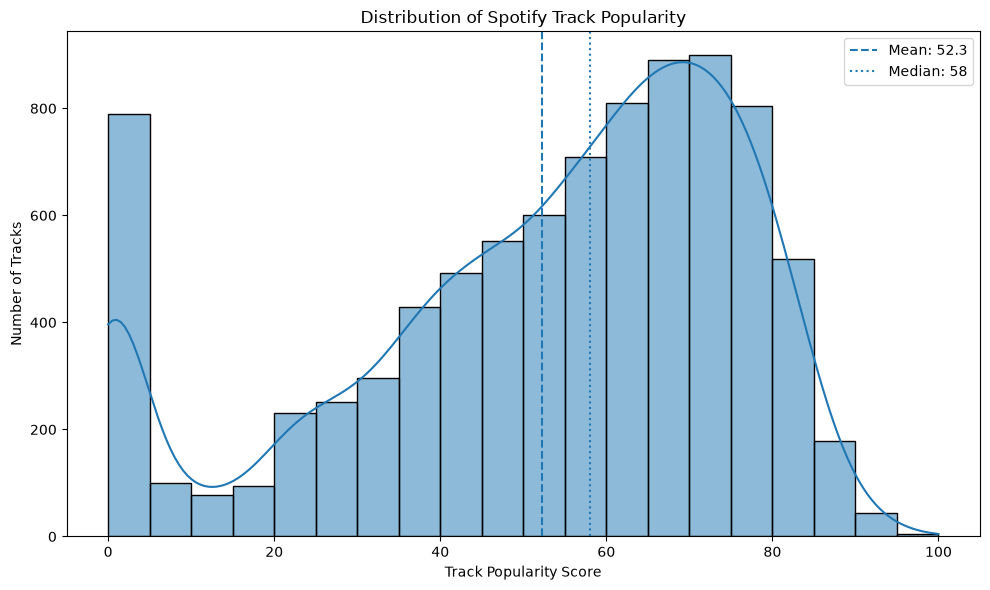

In [8]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="track_popularity",
    bins=20,
    kde=True
)

plt.axvline(
    df["track_popularity"].mean(),
    linestyle="--",
    label=f'Mean: {df["track_popularity"].mean():.1f}'
)

plt.axvline(
    df["track_popularity"].median(),
    linestyle=":",
    label=f'Median: {df["track_popularity"].median():.0f}'
)

plt.title("Distribution of Spotify Track Popularity")
plt.xlabel("Track Popularity Score")
plt.ylabel("Number of Tracks")
plt.legend()

plt.tight_layout()
plt.show()

### Interpretation

Track popularity is concentrated primarily in the middle to upper range of the popularity scale. The median popularity score (58) is higher than the mean (52.3), indicating that lower-popularity observations pull the average downward.

A notable concentration of tracks also appears at or near zero popularity. This pattern should be interpreted cautiously and considered alongside the earlier data quality and exploratory analysis.

This distribution provides baseline context for examining which artist, track, album, genre, and release characteristics are associated with stronger popularity performance.

## Artist Popularity and Track Popularity

This visualization examines the relationship between artist popularity and track popularity.

The objective is to determine whether tracks associated with more popular artists tend to achieve higher track popularity scores.

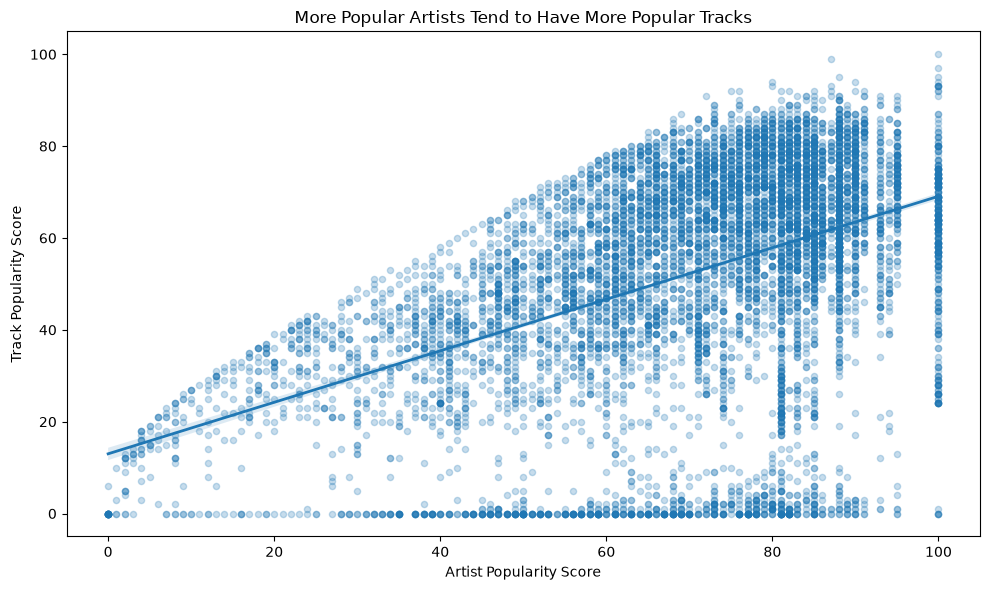

In [9]:
artist_pop_df = df.dropna(
    subset=["artist_popularity", "track_popularity"]
)

plt.figure(figsize=(10, 6))

sns.regplot(
    data=artist_pop_df,
    x="artist_popularity",
    y="track_popularity",
    scatter_kws={"alpha": 0.25, "s": 20},
    line_kws={"linewidth": 2}
)

plt.title("More Popular Artists Tend to Have More Popular Tracks")
plt.xlabel("Artist Popularity Score")
plt.ylabel("Track Popularity Score")

plt.tight_layout()
plt.show()

In [10]:
correlation = artist_pop_df[
    ["artist_popularity", "track_popularity"]
].corr().iloc[0, 1]

print(f"Correlation: {correlation:.3f}")

Correlation: 0.454


### Interpretation

Artist popularity shows a moderate positive relationship with track popularity (r = 0.454).

Tracks from more popular artists tend to achieve higher popularity scores. However, the substantial variation in track popularity at similar levels of artist popularity indicates that artist popularity alone does not determine track performance.

From a business perspective, established artist visibility appears to provide an advantage, but track-level, album, genre, release, and other factors may also contribute to popularity.

### Artist Followers → Track Popularity

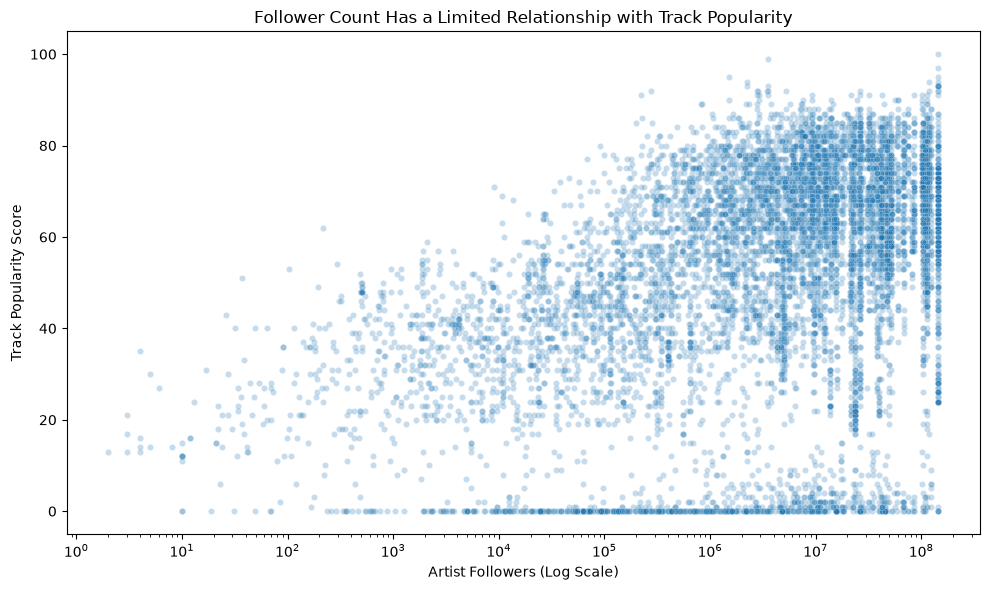

In [14]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=followers_df,
    x="artist_followers",
    y="track_popularity",
    alpha=0.25,
    s=20
)

plt.xscale("log")

plt.title("Follower Count Has a Limited Relationship with Track Popularity")
plt.xlabel("Artist Followers (Log Scale)")
plt.ylabel("Track Popularity Score")

plt.tight_layout()
plt.show()

In [13]:
followers_correlation = followers_df[
    ["artist_followers", "track_popularity"]
].corr().iloc[0, 1]

print(f"Correlation: {followers_correlation:.3f}")

Correlation: 0.226


### Interpretation

Artist follower count has a weak positive relationship with track popularity (r = 0.226).

Tracks from artists with larger follower bases tend to have somewhat higher popularity scores, but the relationship is substantially weaker than the relationship between artist popularity and track popularity (r = 0.454).

This suggests that audience size alone is not a strong indicator of individual track performance. Artist popularity appears to provide a stronger signal of track popularity than raw follower count.

### Explicit vs. Non Explicit Tracks

In [15]:
explicit_summary = (
    df.groupby("explicit")["track_popularity"]
    .agg(["count", "mean", "median"])
    .round(2)
)

explicit_summary

,count,mean,median
explicit,,,
False,6584,50.49,55.0
True,2191,57.54,64.0


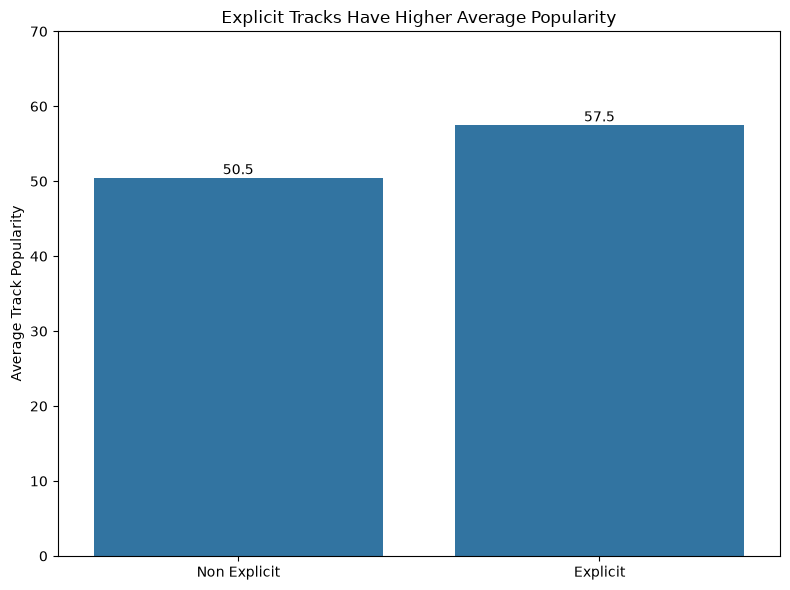

In [16]:
explicit_means = (
    df.groupby("explicit")["track_popularity"]
    .mean()
    .reset_index()
)

explicit_means["explicit"] = explicit_means["explicit"].map({
    False: "Non Explicit",
    True: "Explicit"
})

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=explicit_means,
    x="explicit",
    y="track_popularity"
)

plt.title("Explicit Tracks Have Higher Average Popularity")
plt.xlabel("")
plt.ylabel("Average Track Popularity")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.ylim(0, 70)

plt.tight_layout()
plt.show()

### Interpretation

Explicit tracks have a higher average popularity score (57.54) than non explicit tracks (50.49), representing a difference of approximately 7.05 popularity points.

The median popularity is also higher for explicit tracks (64) than for non explicit tracks (55).

This indicates that explicit tracks in the dataset tend to achieve stronger popularity performance. However, the result represents an association and should not be interpreted as evidence that explicit content itself causes higher popularity. Artist, genre, audience, and release characteristics may also contribute to the observed difference.

### Track Duration → Track Popularity.

In [17]:
duration_correlation = df[
    ["track_duration_min", "track_popularity"]
].corr().iloc[0, 1]

print(f"Correlation: {duration_correlation:.3f}")

Correlation: 0.105


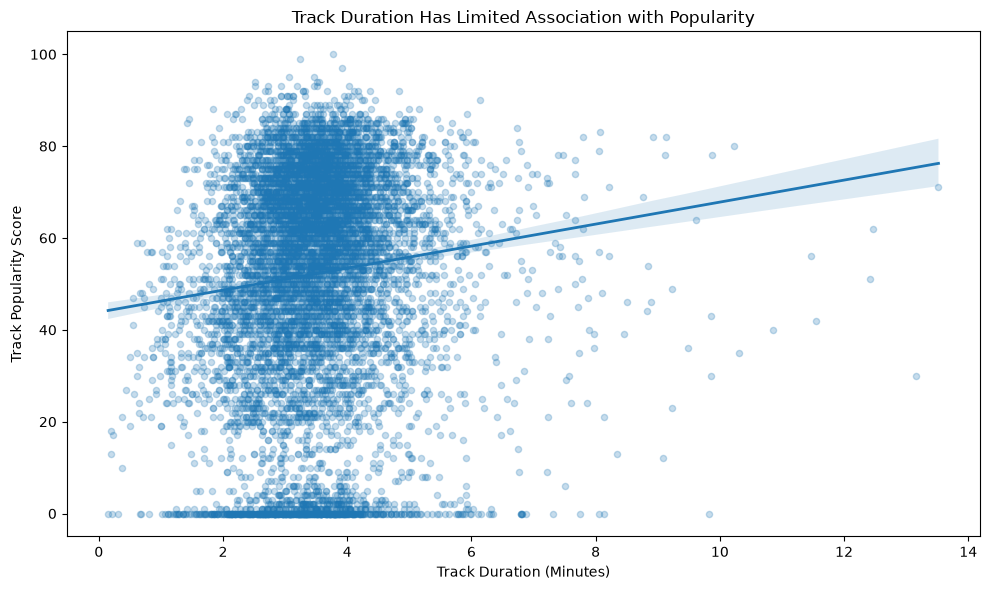

In [18]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x="track_duration_min",
    y="track_popularity",
    scatter_kws={"alpha": 0.25, "s": 20},
    line_kws={"linewidth": 2}
)

plt.title("Track Duration Has Limited Association with Popularity")
plt.xlabel("Track Duration (Minutes)")
plt.ylabel("Track Popularity Score")

plt.tight_layout()
plt.show()

### Interpretation

Track duration has a very weak positive relationship with track popularity (r = 0.105).

Most tracks are concentrated between approximately 2 and 5 minutes, but popularity varies widely within this duration range. This indicates that track length alone provides little information about whether a track will achieve higher popularity.

The positive trend should therefore be interpreted cautiously. The result does not provide evidence that increasing track duration would meaningfully improve track popularity.

### Album Type

In [19]:
album_type_summary = (
    df.groupby("album_type")["track_popularity"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
    .round(2)
)

album_type_summary

,count,mean,median
album_type,,,
album,6022,55.53,61.0
single,2245,46.11,51.0
compilation,508,40.51,44.0


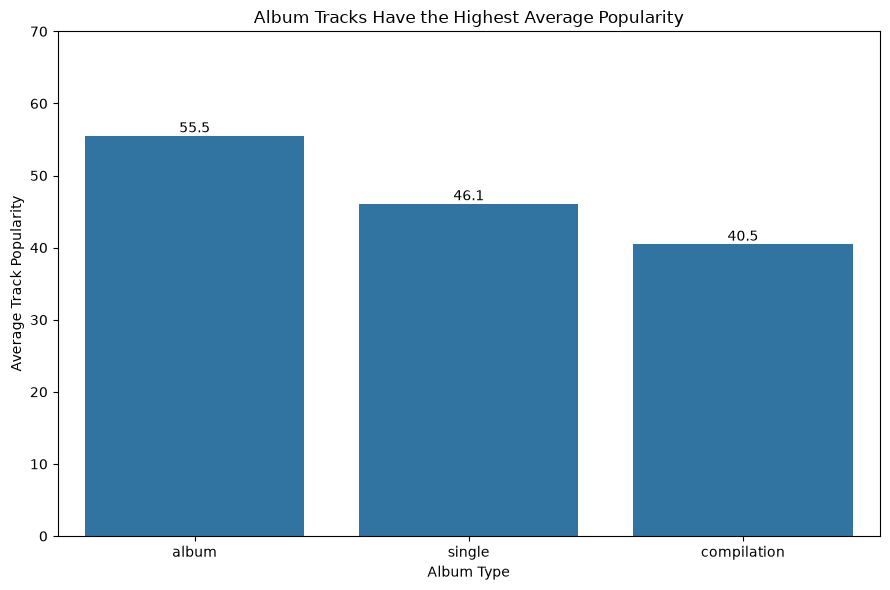

In [20]:
album_type_means = (
    df.groupby("album_type")["track_popularity"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=album_type_means,
    x="album_type",
    y="track_popularity"
)

plt.title("Album Tracks Have the Highest Average Popularity")
plt.xlabel("Album Type")
plt.ylabel("Average Track Popularity")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.ylim(0, 70)

plt.tight_layout()
plt.show()

### Interpretation

Track popularity differs substantially across album types.

Album tracks have the highest average popularity score (55.53), followed by singles (46.11) and compilation tracks (40.51). The median popularity scores follow the same pattern at 61, 51, and 44 respectively.

Album tracks therefore show stronger popularity performance within this dataset. However, this result represents an association rather than evidence that album releases cause higher track popularity. Differences in artist characteristics, genre, release period, and other factors may contribute to the observed pattern.

### Album Size

In [21]:
album_size_correlation = df[
    ["album_total_tracks", "track_popularity"]
].corr().iloc[0, 1]

print(f"Correlation: {album_size_correlation:.3f}")

print("\nAlbum size summary:")
print(df["album_total_tracks"].describe())

Correlation: -0.048

Album size summary:
count    8775.000000
mean       13.783362
std        11.798278
min         1.000000
25%         6.000000
50%        13.000000
75%        17.000000
max       181.000000
Name: album_total_tracks, dtype: float64


### Interpretation

Album size has a negligible negative relationship with track popularity (r = -0.048).

The number of tracks on an album therefore provides little indication of individual track popularity in this dataset. Both shorter and longer releases can contain tracks across a wide range of popularity levels.

From a business perspective, release size alone does not appear to be a meaningful indicator of track performance.

### Genre

In [23]:
genre_df = df.dropna(
    subset=["artist_genres", "track_popularity"]
).copy()

print("Tracks with genre information:", len(genre_df))
print("Tracks without genre information:", df["artist_genres"].isna().sum())

print("\nUnique genre values:")
print(genre_df["artist_genres"].nunique())

print("\nMost common genre values:")
print(genre_df["artist_genres"].value_counts().head(15))

Tracks with genre information: 4283
Tracks without genre information: 4492

Unique genre values:
652

Most common genre values:
artist_genres
soundtrack                                      346
pop                                             303
soft pop                                        209
rap                                             192
dark r&b                                        111
k-pop                                            93
grunge, rock                                     91
country                                          90
edm                                              82
rap, hip hop                                     77
country, acoustic country                        73
art pop, pop                                     72
r&b                                              65
emo rap, cloud rap                               63
reggaeton, trap latino, urbano latino, latin     56
Name: count, dtype: int64


In [24]:
genre_summary = (
    genre_df.groupby("artist_genres")
    .agg(
        track_count=("track_popularity", "size"),
        avg_popularity=("track_popularity", "mean"),
        median_popularity=("track_popularity", "median")
    )
    .reset_index()
)

genre_summary = genre_summary[
    genre_summary["track_count"] >= 30
].sort_values(
    "avg_popularity",
    ascending=False
)

genre_summary.head(15)

,artist_genres,track_count,avg_popularity,median_popularity
533,"reggaeton, trap latino, urbano latino, latin",56,73.339286,75.0
369,k-pop,93,66.172043,68.0
454,"nu metal, rap metal, rock, alternative metal",38,66.078947,68.5
515,rap,192,66.057292,69.0
326,"hyperpop, art pop",30,65.900000,66.0
513,rage rap,49,65.183673,64.0
47,"art rock, alternative rock",41,62.951220,63.0
511,r&b,65,62.169231,69.0
219,edm,82,61.987805,69.0
471,pop,303,61.943894,66.0


In [25]:
print("Genre groups before threshold:", genre_df["artist_genres"].nunique())
print("Genre groups with at least 30 tracks:", len(genre_summary))
print("Tracks represented after threshold:", genre_summary["track_count"].sum())

Genre groups before threshold: 652
Genre groups with at least 30 tracks: 27
Tracks represented after threshold: 2400


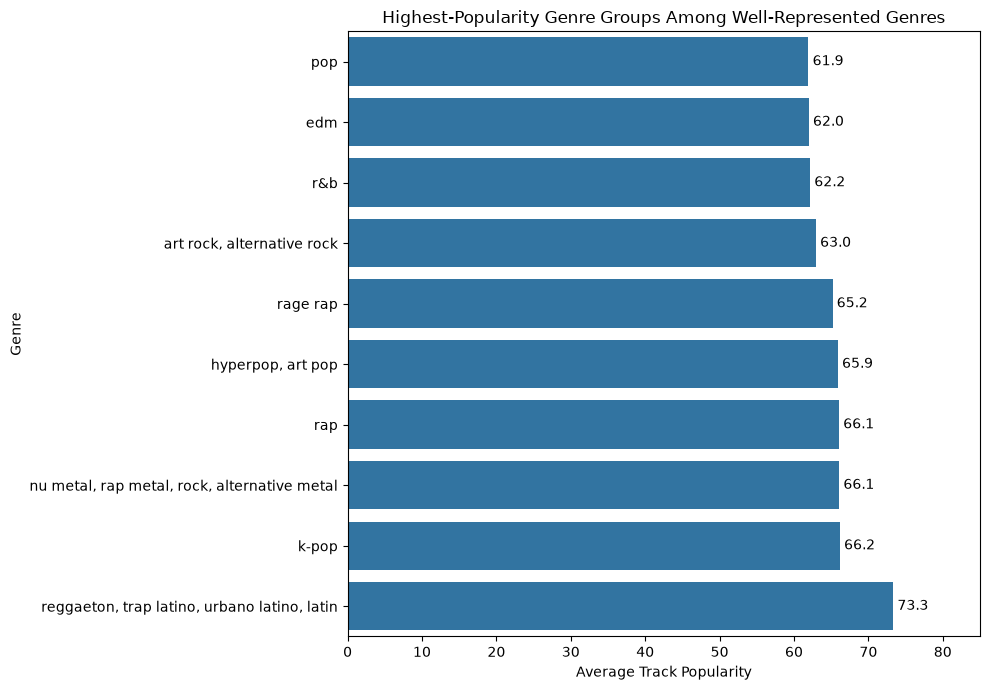

In [26]:
top_genres = genre_summary.head(10).sort_values(
    "avg_popularity",
    ascending=True
)

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=top_genres,
    x="avg_popularity",
    y="artist_genres"
)

plt.title("Highest-Popularity Genre Groups Among Well-Represented Genres")
plt.xlabel("Average Track Popularity")
plt.ylabel("Genre")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.xlim(0, 85)

plt.tight_layout()
plt.show()

### Interpretation

Among genre groups represented by at least 30 tracks, the reggaeton, trap latino, urbano latino, and latin combination has the highest average track popularity at 73.34.

K-pop, nu metal and related rock genres, rap, hyperpop and art pop, and rage rap also show relatively high average popularity within the qualifying genre groups.

These results should be interpreted cautiously because genre metadata is available for only 4,283 of the 8,775 tracks. In addition, the `artist_genres` field may contain multiple genre labels for the same artist. The results therefore describe patterns within the available genre-labelled subset rather than the full dataset.

### Release Period 

In [28]:
release_summary = (
    df.groupby("release_year")["track_popularity"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

release_summary.tail(20)

,release_year,count,mean,median
48,2006,97,55.113402,61.0
49,2007,110,51.590909,54.0
50,2008,103,51.310680,57.0
51,2009,158,49.417722,54.0
52,2010,251,51.864542,57.0
53,2011,271,50.040590,56.0
54,2012,336,51.491071,56.0
55,2013,316,49.958861,54.0
56,2014,353,52.696884,57.0
57,2015,405,53.217284,59.0


In [29]:
df["release_decade"] = (df["release_year"] // 10) * 10

decade_summary = (
    df.groupby("release_decade")["track_popularity"]
    .agg(["count", "mean", "median"])
    .round(2)
)

decade_summary

,count,mean,median
release_decade,,,
1950,7,53.57,58.0
1960,50,52.66,57.5
1970,80,63.70,72.0
1980,100,59.68,64.0
1990,406,51.05,58.0
2000,937,53.09,57.0
2010,3827,51.96,58.0
2020,3368,51.99,57.0


In [30]:
print("Tracks by decade:")
print(df["release_decade"].value_counts().sort_index())

Tracks by decade:
release_decade
1950       7
1960      50
1970      80
1980     100
1990     406
2000     937
2010    3827
2020    3368
Name: count, dtype: int64


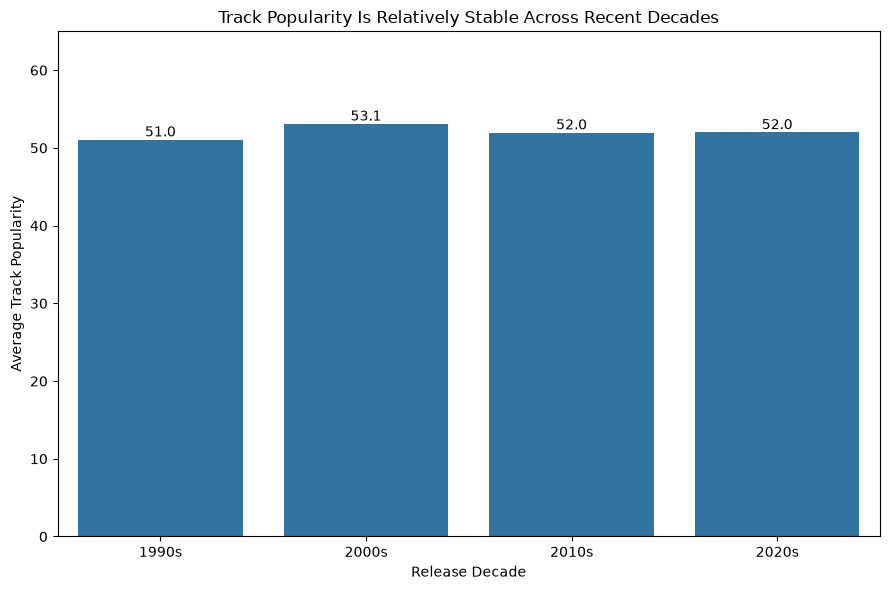

In [31]:
recent_decades = decade_summary.loc[1990:].reset_index()

recent_decades["decade"] = (
    recent_decades["release_decade"]
    .astype(str)
    .str[:3] + "0s"
)

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=recent_decades,
    x="decade",
    y="mean"
)

plt.title("Track Popularity Is Relatively Stable Across Recent Decades")
plt.xlabel("Release Decade")
plt.ylabel("Average Track Popularity")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.ylim(0, 65)
plt.tight_layout()
plt.show()

### Interpretation

Among the better-represented release decades from the 1990s onward, average track popularity is relatively stable.

Average popularity ranges from 51.05 for tracks released in the 1990s to 53.09 for tracks released in the 2000s. Tracks from the 2010s and 2020s have nearly identical average popularity scores of approximately 52.

Earlier decades show some higher average popularity values, particularly the 1970s and 1980s, but these periods contain substantially fewer observations and should therefore be interpreted cautiously.

Overall, the results do not indicate that more recently released tracks are systematically more popular within this dataset.

### Which artists demonstrate the strongest popularity performance with sufficient track representation?

In [32]:
artist_counts = (
    df.dropna(subset=["artist_name"])
    ["artist_name"]
    .value_counts()
)

print("Unique artists:", artist_counts.size)

print("\nArtist track count summary:")
print(artist_counts.describe())

print("\nArtists with the most tracks:")
print(artist_counts.head(15))

Unique artists: 2546

Artist track count summary:
count    2546.000000
mean        3.445797
std        10.372834
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       331.000000
Name: count, dtype: float64

Artists with the most tracks:
artist_name
Taylor Swift         331
The Weeknd           151
Ariana Grande        101
Lana Del Rey         100
Nirvana               91
Drake                 86
Post Malone           83
The Neighbourhood     77
Lady Gaga             72
Olivia Rodrigo        70
Eminem                68
Miley Cyrus           62
Justin Bieber         62
Billie Eilish         61
Lil Peep              61
Name: count, dtype: int64


In [33]:
print("Artists with at least 5 tracks:", (artist_counts >= 5).sum())
print("Artists with at least 10 tracks:", (artist_counts >= 10).sum())
print("Artists with at least 20 tracks:", (artist_counts >= 20).sum())
print("Artists with at least 30 tracks:", (artist_counts >= 30).sum())

print("\nTracks represented by artists with at least 10 tracks:")
eligible_artists = artist_counts[artist_counts >= 10].index

print(
    df[df["artist_name"].isin(eligible_artists)].shape[0]
)

Artists with at least 5 tracks: 344
Artists with at least 10 tracks: 155
Artists with at least 20 tracks: 66
Artists with at least 30 tracks: 42

Tracks represented by artists with at least 10 tracks:
4333


In [34]:
artist_summary = (
    df[df["artist_name"].isin(eligible_artists)]
    .groupby("artist_name")
    .agg(
        track_count=("track_popularity", "size"),
        avg_popularity=("track_popularity", "mean"),
        median_popularity=("track_popularity", "median")
    )
    .reset_index()
    .sort_values("avg_popularity", ascending=False)
)

artist_summary.head(15)

,artist_name,track_count,avg_popularity,median_popularity
7,Arctic Monkeys,10,79.800000,82.0
154,sombr,15,79.666667,78.0
125,Sabrina Carpenter,37,77.945946,82.0
137,Tame Impala,13,75.000000,77.0
17,Billie Eilish,61,73.885246,74.0
27,Chappell Roan,18,73.611111,72.5
13,Bad Bunny,56,73.339286,75.0
72,Justin Timberlake,10,72.400000,73.0
136,TV Girl,16,72.250000,73.0
1,Addison Rae,10,71.100000,70.0


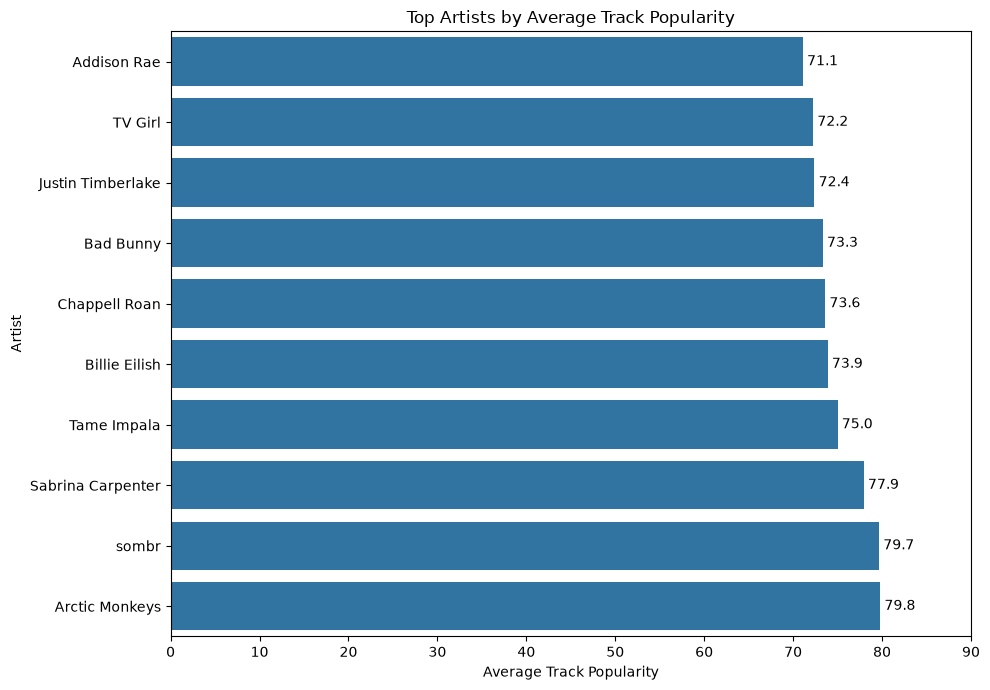

In [35]:
top_artists = (
    artist_summary
    .head(10)
    .sort_values("avg_popularity", ascending=True)
)

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=top_artists,
    x="avg_popularity",
    y="artist_name"
)

plt.title("Top Artists by Average Track Popularity")
plt.xlabel("Average Track Popularity")
plt.ylabel("Artist")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.xlim(0, 90)

plt.tight_layout()
plt.show()

### Interpretation

Among artists represented by at least 10 tracks, Arctic Monkeys have the highest average track popularity at 79.8, closely followed by sombr at 79.7 and Sabrina Carpenter at 77.9.

The median popularity values generally support the average-based ranking, indicating that the results are not solely driven by individual highly popular tracks.

However, track representation varies across qualifying artists. For example, Arctic Monkeys are represented by 10 tracks, while Billie Eilish and Bad Bunny are represented by 61 and 56 tracks respectively. The ranking should therefore be interpreted as average performance among sufficiently represented artists rather than a definitive ranking of overall artist success.

### Top Track Performance and Concentration.

In [36]:
print("Maximum track popularity:", df["track_popularity"].max())

print("\nTracks with popularity >= 90:")
print((df["track_popularity"] >= 90).sum())

print("\nTracks with popularity >= 95:")
print((df["track_popularity"] >= 95).sum())

print("\nTracks with popularity == 100:")
print((df["track_popularity"] == 100).sum())

Maximum track popularity: 100

Tracks with popularity >= 90:
49

Tracks with popularity >= 95:
5

Tracks with popularity == 100:
1


In [37]:
top_tracks = (
    df[
        [
            "track_name",
            "artist_name",
            "track_popularity",
            "release_year"
        ]
    ]
    .sort_values(
        "track_popularity",
        ascending=False
    )
    .head(20)
)

top_tracks

,track_name,artist_name,track_popularity,release_year
7090,The Fate of Ophelia,Taylor Swift,100,2025
4370,Golden,HUNTR/X,99,2025
5494,Opalite,Taylor Swift,97,2025
3634,Man I Need,Olivia Dean,95,2025
6448,Elizabeth Taylor,Taylor Swift,95,2025
1390,BIRDS OF A FEATHER,Billie Eilish,94,2024
3125,Soda Pop,Saja Boys,94,2025
8656,Father Figure,Taylor Swift,94,2025
2829,CANCELLED!,Taylor Swift,93,2025
2556,Actually Romantic,Taylor Swift,93,2025


In [38]:
high_pop_tracks = df[
    df["track_popularity"] >= 90
].copy()

print("High-popularity tracks:", len(high_pop_tracks))

print("\nBy release year:")
print(
    high_pop_tracks["release_year"]
    .value_counts()
    .sort_index()
)

print("\nBy artist:")
print(
    high_pop_tracks["artist_name"]
    .value_counts()
    .head(15)
)

High-popularity tracks: 49

By release year:
release_year
1983     1
1993     1
1998     1
2000     2
2013     2
2023     1
2024     5
2025    36
Name: count, dtype: int64

By artist:
artist_name
Taylor Swift         12
HUNTR/X               4
sombr                 2
The Weeknd            2
Billie Eilish         2
Coldplay              2
Bad Bunny             2
Saja Boys             2
Olivia Dean           2
Alex Warren           2
Sabrina Carpenter     2
Tate McRae            2
Justin Bieber         1
KATSEYE               1
The Goo Goo Dolls     1
Name: count, dtype: int64


In [39]:
recent_high_pop = (
    high_pop_tracks["release_year"] >= 2024
).mean() * 100

print(
    f"Share of 90+ popularity tracks released in 2024-2025: "
    f"{recent_high_pop:.1f}%"
)

Share of 90+ popularity tracks released in 2024-2025: 83.7%


In [40]:
top_artist_counts = (
    high_pop_tracks["artist_name"]
    .value_counts()
)

top_artist_share = (
    top_artist_counts.iloc[0] / len(high_pop_tracks)
) * 100

print("Artist with most 90+ tracks:", top_artist_counts.index[0])
print("Number of 90+ tracks:", top_artist_counts.iloc[0])
print(f"Share of all 90+ tracks: {top_artist_share:.1f}%")

Artist with most 90+ tracks: Taylor Swift
Number of 90+ tracks: 12
Share of all 90+ tracks: 24.5%


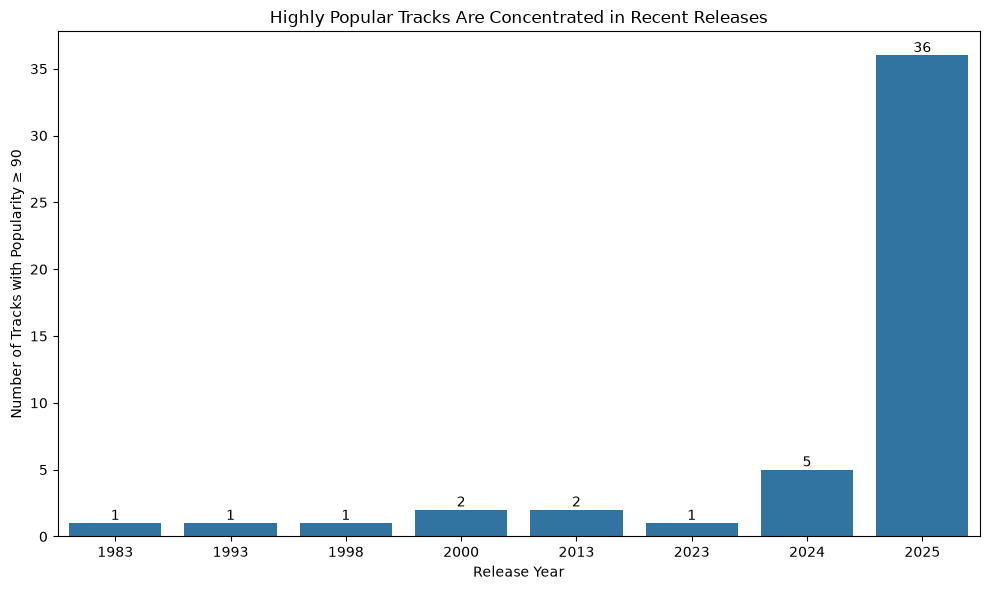

In [41]:
high_pop_by_year = (
    high_pop_tracks["release_year"]
    .value_counts()
    .sort_index()
    .reset_index()
)

high_pop_by_year.columns = [
    "release_year",
    "track_count"
]

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=high_pop_by_year,
    x="release_year",
    y="track_count"
)

plt.title("Highly Popular Tracks Are Concentrated in Recent Releases")
plt.xlabel("Release Year")
plt.ylabel("Number of Tracks with Popularity ≥ 90")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Interpretation

Highly popular tracks are strongly concentrated among recent releases in this dataset.

Of the 49 tracks with popularity scores of 90 or higher, 36 were released in 2025 and 5 were released in 2024. Together, releases from 2024 and 2025 account for 83.7% of all tracks in the 90+ popularity group.

Artist concentration is also evident. Taylor Swift accounts for 12 of the 49 highly popular tracks, representing 24.5% of the group.

This finding complements the release-period analysis. While average track popularity remains relatively stable across recent decades, the extreme upper end of the popularity distribution is disproportionately represented by recent releases.

The result should be interpreted as concentration within this dataset rather than evidence that recent release timing or particular artists directly cause higher popularity.

# Final Visualization Selection

The final visualization stage focuses on the findings that provide the strongest evidence for the business problem.

Not every exploratory chart is included in the stakeholder presentation. Visuals are selected based on analytical strength, business relevance, interpretability, and their contribution to the overall story.

The final narrative is organized around five themes:

1. Artist visibility
2. Track and release characteristics
3. Genre and artist performance
4. Release timing and extreme popularity
5. Predictive modeling and decision support

## Visualization Selection

### Keep

- Artist Popularity vs Track Popularity
- Explicit vs Non Explicit Track Popularity
- Popularity by Album Type
- Top Genre Groups by Average Popularity
- Top Artists by Average Popularity with Minimum Track Representation
- High Popularity Tracks by Release Year
- Model Performance Comparison
- Permutation Feature Importance

### Combine

- Artist Followers vs Track Popularity with Artist Popularity analysis
- Track Duration and Album Size findings into supporting evidence for track characteristics
- Release Decade averages with the high popularity release-year analysis

### Supporting Only

- Overall Track Popularity Distribution
- Artist Followers scatterplot
- Track Duration scatterplot
- Album Size relationship
- Average Popularity by Recent Decade

These findings remain important for analytical completeness but do not require individual stakeholder slides.

### Remove from Final Presentation

Charts that repeat the same message, provide weak business differentiation, or add complexity without changing the decision should remain in the analytical notebooks rather than the final presentation.

# Theme 1: Artist Visibility

## Artist Visibility Emerges as the Strongest Popularity Signal

The analysis consistently indicates that artist-level visibility is more strongly associated with track popularity than most individual track characteristics.

Artist popularity has a moderate positive relationship with track popularity (r = 0.454), while artist follower count shows a weaker positive relationship (r = 0.226).

The machine learning analysis reinforces this finding. Held-out permutation importance identifies artist popularity as the strongest predictive feature in Random Forest Model B.

Together, the descriptive and predictive evidence suggests that existing artist visibility provides meaningful information about track popularity, although these relationships should not be interpreted as causal.

### Business Implication

Track performance should be evaluated within the context of the artist's existing market visibility. Artist popularity provides a stronger signal than follower count alone, suggesting that audience size by itself does not fully represent an artist's current market position.

For release strategy, artist-level visibility should therefore be considered alongside track and release characteristics rather than treating songs as independent products.

# Theme 2: Track and Release Characteristics

## Some Release Characteristics Matter More Than Others

Track and release characteristics show different levels of association with popularity.

Explicit tracks recorded an average popularity score approximately 7 points higher than non explicit tracks. Album tracks also showed higher average popularity than singles and compilation tracks.

In contrast, track duration had only a very weak relationship with popularity (r = 0.105), while album size showed a negligible linear relationship (r = -0.048).

These results indicate that no single structural characteristic of a track consistently explains popularity.

### Key Evidence

- Explicit tracks: average popularity approximately 57.5
- Non explicit tracks: average popularity approximately 50.5
- Difference: approximately +7.0 points

- Album tracks: average popularity approximately 55.5
- Singles: average popularity approximately 46.1
- Compilations: average popularity approximately 40.5

- Track duration vs popularity: r = 0.105
- Album size vs popularity: r = -0.048

### Business Implication

Release strategy appears more informative than simple physical characteristics such as track duration.

The higher observed popularity of explicit tracks and album tracks may help identify patterns in the current catalog, but these associations should not be interpreted as evidence that making a track explicit or releasing it as part of an album will increase popularity.

Track and release characteristics should therefore be considered as contextual signals rather than standalone rules for predicting success.

# Theme 3: Genre and Artist Performance

## Popularity Varies Across Genres and Artists

Track popularity differs across genre groups and artists, but these comparisons require sufficient representation to avoid rankings based on only a few observations.

For the genre analysis, only genre groups represented by at least 30 tracks were compared. Among qualifying groups, Latin-oriented genres, K-pop, rap, and several rock and alternative categories appeared among the stronger average performers.

For the artist analysis, a minimum threshold of 10 tracks per artist was used. This provides a more stable comparison than ranking artists represented by only one or a few tracks.

### Key Evidence

Genre analysis:

- 4,283 tracks contain genre information.
- 4,492 tracks have missing genre information.
- 27 genre groups met the minimum threshold of 30 tracks.
- These qualifying groups represent approximately 2,400 tracks.

Among the higher-average qualifying genre groups were:

- Reggaeton / Trap Latino / Urbano Latino / Latin: average popularity 73.3
- K-pop: 66.2
- Nu Metal / Rap Metal / Rock / Alternative Metal: 66.1
- Rap: 66.1

Artist analysis:

- 2,546 unique artists are represented in the dataset.
- 155 artists have at least 10 represented tracks.
- These artists account for 4,333 tracks.

Among artists meeting the 10-track threshold, several artists achieved average popularity scores above 70.

### Business Implication

Genre and artist-level performance can support audience segmentation and benchmarking, but rankings should be interpreted within the boundaries of the dataset.

Genre results are particularly sensitive to data availability because genre information is missing for approximately half of the tracks. The genre field also contains multi-genre labels rather than a single standardized genre taxonomy.

For strategy teams, these findings are therefore more useful for identifying segments worth further investigation than for declaring one genre or artist universally more successful.

# Theme 4: Release Timing and Extreme Popularity

## Recent Releases Dominate the Highest Popularity Scores

Average track popularity does not show a strong upward pattern across the better-represented recent decades.

However, a different pattern emerges when the analysis focuses specifically on exceptionally high-popularity tracks.

Among the 49 tracks with popularity scores of 90 or higher, 41 were released in 2024 or 2025. This means that 83.7% of the highest-popularity tracks in the dataset are concentrated in the two most recent release years.

This distinction is important: recent tracks do not necessarily have dramatically higher average popularity, but they are strongly represented at the extreme upper end of the popularity distribution.

### Key Evidence

Average popularity across recent decades:

- 1990s: 51.1
- 2000s: 53.1
- 2010s: 52.0
- 2020s: 52.0

High-popularity tracks with popularity >= 90:

- Total: 49 tracks
- Released in 2024: 5 tracks
- Released in 2025: 36 tracks
- Released in 2024–2025: 41 tracks
- Share released in 2024–2025: 83.7%

The results therefore show different patterns for average performance and extreme performance.

### Business Implication

Release recency appears particularly relevant when examining the highest-performing tracks rather than average popularity across the full catalog.

For music strategy teams, this suggests that catalog-wide averages can hide important patterns at the upper end of the popularity distribution. Recent releases are disproportionately represented among the dataset's highest-popularity tracks.

However, this result should be interpreted in the context of Spotify's current popularity measure. The analysis does not demonstrate that recent release timing causes higher popularity, and older tracks may face different measurement and exposure conditions.

# Theme 5: Predictive Modeling and Decision Support

## Popularity Contains Predictive Signal, but Hit Prediction Remains Difficult

Machine learning was used to evaluate whether track, release, genre, and artist characteristics can distinguish high-popularity tracks from the rest of the catalog.

The results show that intrinsic track and release characteristics alone provide limited predictive performance. Adding artist-level information improves the model, reinforcing the importance of artist visibility identified in the earlier analysis.

However, even the strongest model misses a substantial proportion of high-popularity tracks. The model should therefore be interpreted as a decision-support tool rather than a reliable hit-prediction system.

### Key Evidence

Model performance:

- Dummy baseline accuracy: 73.5%
- Logistic Regression Model B:
  - Accuracy: 74.0%
  - Precision: 52.5%
  - Recall: 22.2%
  - F1: 0.312

- Random Forest Model A:
  - Accuracy: 69.4%
  - F1: approximately 0.320

- Random Forest Model B:
  - Accuracy: 76.7%
  - Precision: 60.0%
  - Recall: 36.0%
  - F1: 0.450

Five-fold group-aware cross-validation for Random Forest Model B:

- Mean accuracy: 76.8%
- Mean precision: 57.8%
- Mean recall: 37.5%
- Mean F1: 0.454
- F1 standard deviation: 0.012

The close agreement between holdout and cross-validation performance indicates that Model B is relatively stable across different groups of tracks.

### What Drives the Model?

Held-out permutation importance identifies Artist Popularity as the strongest predictive feature for high track popularity.

The leading features include:

1. Artist Popularity
2. Album Size
3. Track Duration
4. Artist Followers
5. Release in the 2020s

Artist Popularity produces the largest deterioration in F1 score when shuffled, providing additional evidence that artist-level visibility contains substantial predictive information.

Feature importance represents predictive contribution within the model and should not be interpreted as evidence of causation.

### Business Implication

The machine learning results reinforce rather than replace the descriptive and statistical analysis.

Artist-level visibility improves the ability to distinguish high-popularity tracks, but popularity cannot be reliably predicted from the available variables alone.

For artists, labels, and music strategy teams, the model is better suited to identifying patterns and supporting release decisions than forecasting individual hits.

Additional factors such as playlist placement, marketing activity, social media exposure, geographic audience behavior, and changes in popularity over time may be necessary for stronger predictive performance.

## Model Performance Comparison

Model performance is compared using precision, recall, and F1 score for the high-popularity class.

These metrics are emphasized instead of accuracy because approximately three quarters of tracks belong to the non-high-popularity class. A model can therefore achieve relatively high accuracy while still performing poorly at identifying high-popularity tracks.

In [42]:
model_performance = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest A",
        "Random Forest B"
    ],
    "Precision": [
        0.525,
        0.389,
        0.600
    ],
    "Recall": [
        0.222,
        0.267,
        0.360
    ],
    "F1": [
        0.312,
        0.320,
        0.450
    ]
})

model_performance

,Model,Precision,Recall,F1
0,Logistic Regression,0.525,0.222,0.312
1,Random Forest A,0.389,0.267,0.320
2,Random Forest B,0.600,0.360,0.450


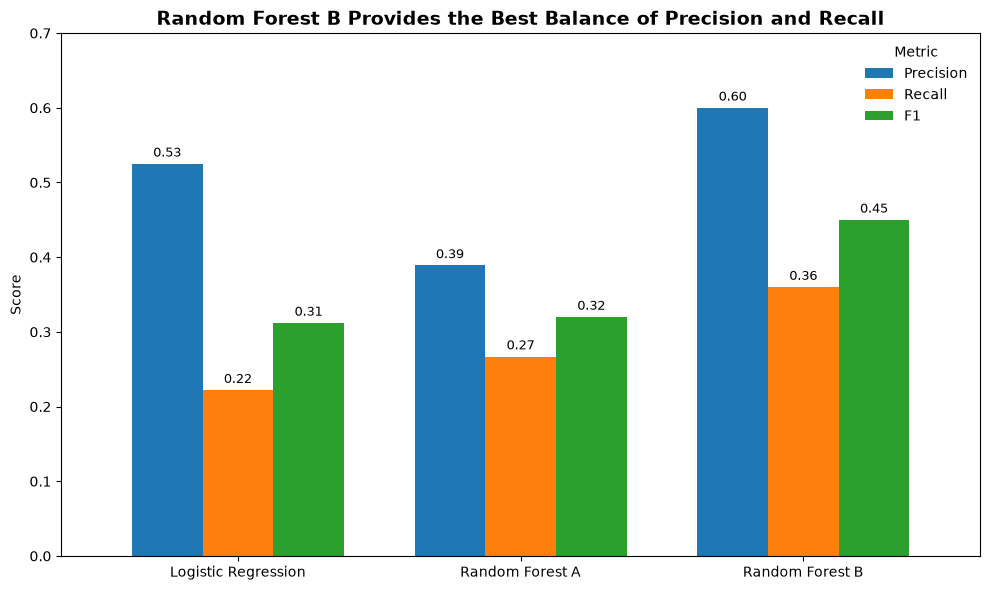

In [44]:
model_performance_plot = model_performance.set_index("Model")

ax = model_performance_plot.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.75
)

plt.title(
    "Random Forest B Provides the Best Balance of Precision and Recall",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Score")
plt.ylim(0, 0.7)

plt.xticks(rotation=0)

plt.legend(
    title="Metric",
    frameon=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

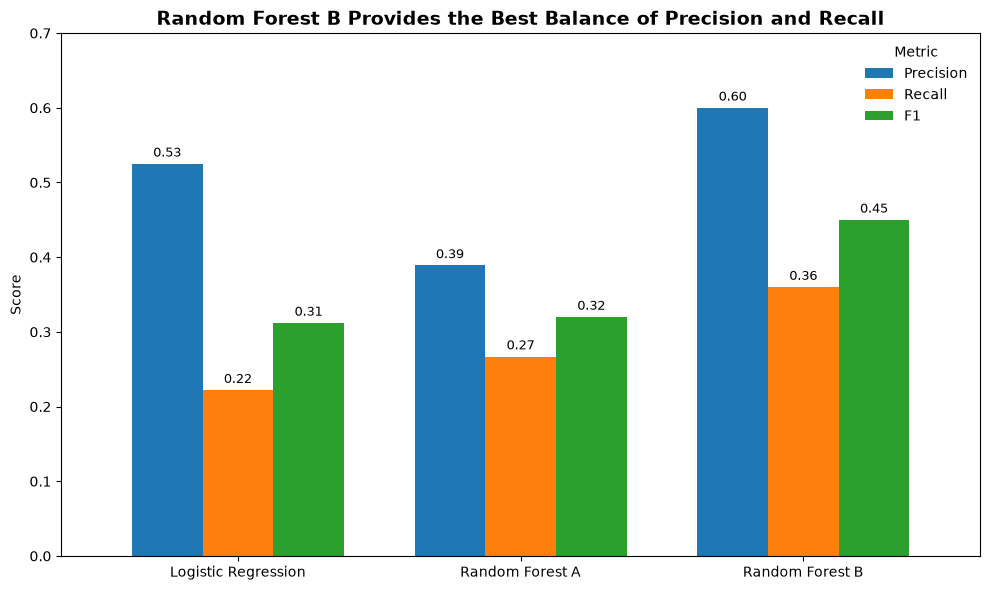

In [45]:
model_performance_plot = model_performance.set_index("Model")

ax = model_performance_plot.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.75
)

plt.title(
    "Random Forest B Provides the Best Balance of Precision and Recall",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Score")
plt.ylim(0, 0.7)
plt.xticks(rotation=0)

plt.legend(
    title="Metric",
    frameon=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

# Final Insights and Action Plan

## Key Insights

### 1. Artist visibility is the strongest recurring popularity signal

Artist popularity shows a moderate positive relationship with track popularity and emerges as the strongest predictive feature in the machine learning analysis. Artist follower count provides additional information but shows a weaker standalone relationship.

### 2. Track characteristics alone do not explain popularity

Explicit tracks and album releases show higher average popularity in this dataset, while track duration and album size have weak or negligible standalone linear relationships with popularity.

This indicates that popularity cannot be reduced to a simple formula based on track characteristics.

### 3. Genre and artist performance provide useful segmentation

Popularity varies across sufficiently represented genre groups and artists. These comparisons can support benchmarking and audience segmentation, although incomplete genre information limits the strength of genre-level conclusions.

### 4. Extreme popularity is concentrated among recent releases

Average popularity remains relatively stable across the better-represented recent decades, but 83.7% of tracks with popularity scores of 90 or higher were released in 2024 or 2025.

Recent releases therefore dominate the extreme upper end of the popularity distribution in this dataset.

### 5. Machine learning provides decision support, not reliable hit prediction

Random Forest Model B produced the strongest predictive performance and remained stable under group-aware cross-validation.

However, average recall was only 37.5%, meaning that most high-popularity tracks were still missed.

The model should therefore support analytical decision making rather than be used as a standalone hit-prediction system.

## Recommended Actions

### Prioritize artist positioning

Incorporate artist popularity and current market visibility into release planning and performance benchmarking rather than relying primarily on follower count.

### Evaluate releases using multiple signals

Combine artist visibility, release format, genre context, timing, and track characteristics instead of using any individual variable as a rule for success.

### Monitor recent releases separately from catalog performance

Separate current-release performance from long-term catalog analysis because extreme popularity is strongly concentrated among recent releases in this dataset.

### Use segmentation rather than universal benchmarks

Compare tracks within relevant artist, genre, and release contexts where possible rather than applying one popularity benchmark across the entire catalog.

### Expand the data before operationalizing prediction

Future predictive work should incorporate variables such as playlist placement, marketing activity, social media exposure, geographic audience behavior, and longitudinal popularity measures.

## Final Takeaway

Track popularity emerges from a combination of artist visibility, release context, market segmentation, and other factors not fully captured by the available dataset.

The strongest and most consistent finding is the importance of artist-level visibility. However, no individual feature or current model is sufficient to reliably determine which tracks will achieve high popularity.

The analysis therefore supports a multi-factor, evidence-based approach to music release and content strategy.

In [46]:
TABLEAU_DATA = PROJECT_ROOT / "data" / "tableau"
TABLEAU_DATA.mkdir(parents=True, exist_ok=True)

print("Tableau data folder:", TABLEAU_DATA)

Tableau data folder: ../data/tableau


In [47]:
tableau_columns = [
    "track_id",
    "track_name",
    "track_popularity",
    "explicit",
    "artist_name",
    "artist_popularity",
    "artist_followers",
    "artist_genres",
    "album_name",
    "album_type",
    "album_total_tracks",
    "track_duration_min",
    "release_year"
]

tableau_df = df[tableau_columns].copy()

print("Tableau dataset shape:", tableau_df.shape)
tableau_df.head()

Tableau dataset shape: (8775, 13)


,track_id,track_name,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_name,album_type,album_total_tracks,track_duration_min,release_year
0,6pymOcrCnMuCWdgGVTvUgP,3,61,False,Britney Spears,80.0,17755451.0,pop,The Singles Collection,compilation,58,3.55,2009
1,2lWc1iJlz2NVcStV5fbtPG,Clouds,67,False,BUNT.,69.0,293734.0,stutter house,Clouds,single,1,2.65,2023
2,1msEuwSBneBKpVCZQcFTsU,Forever & Always (Taylor’s Version),63,False,Taylor Swift,100.0,145396321.0,NaN,Fearless (Taylor's Version),album,26,3.76,2021
3,7bcy34fBT2ap1L4bfPsl9q,I Didn't Change My Number,72,True,Billie Eilish,90.0,118692183.0,NaN,Happier Than Ever,album,16,2.64,2021
4,0GLfodYacy3BJE7AI3A8en,Man Down,57,False,Rihanna,90.0,68997177.0,NaN,Loud,album,13,4.45,2010


In [51]:
tableau_df.rename(
    columns={"high_popularity": "popularity_90_plus"},
    inplace=True
)

In [52]:
# Release decade
tableau_df["release_decade"] = (
    (tableau_df["release_year"] // 10) * 10
).astype(str) + "s"

# High-popularity flag
tableau_df["high_popularity"] = (
    tableau_df["track_popularity"] >= 90
)

# Recent-release flag used in the 90+ analysis
tableau_df["recent_release"] = (
    tableau_df["release_year"].isin([2024, 2025])
)

# Explicit label for cleaner Tableau display
tableau_df["explicit_label"] = np.where(
    tableau_df["explicit"],
    "Explicit",
    "Non Explicit"
)

# Genre availability
tableau_df["genre_available"] = np.where(
    tableau_df["artist_genres"].notna(),
    "Genre Available",
    "Genre Missing"
)

In [53]:
print("Shape:", tableau_df.shape)

print("\nRelease decades:")
print(tableau_df["release_decade"].value_counts().sort_index())

print("\n90+ popularity:")
print(tableau_df["popularity_90_plus"].value_counts())

print("\nRecent release:")
print(tableau_df["recent_release"].value_counts())

print("\nExplicit:")
print(tableau_df["explicit_label"].value_counts())

print("\nGenre availability:")
print(tableau_df["genre_available"].value_counts())

Shape: (8775, 19)

Release decades:
release_decade
1950s       7
1960s      50
1970s      80
1980s     100
1990s     406
2000s     937
2010s    3827
2020s    3368
Name: count, dtype: int64

90+ popularity:
popularity_90_plus
False    8726
True       49
Name: count, dtype: int64

Recent release:
recent_release
False    7349
True     1426
Name: count, dtype: int64

Explicit:
explicit_label
Non Explicit    6584
Explicit        2191
Name: count, dtype: int64

Genre availability:
genre_available
Genre Missing      4492
Genre Available    4283
Name: count, dtype: int64


In [54]:
print(tableau_df.columns.tolist())

['track_id', 'track_name', 'track_popularity', 'explicit', 'artist_name', 'artist_popularity', 'artist_followers', 'artist_genres', 'album_name', 'album_type', 'album_total_tracks', 'track_duration_min', 'release_year', 'release_decade', 'popularity_90_plus', 'recent_release', 'explicit_label', 'genre_available', 'high_popularity']


In [55]:
if "high_popularity" in tableau_df.columns:
    tableau_df = tableau_df.drop(columns="high_popularity")

print("Shape after cleanup:", tableau_df.shape)

Shape after cleanup: (8775, 18)


In [56]:
# Number of tracks represented for each artist
tableau_df["artist_track_count"] = (
    tableau_df
    .groupby("artist_name")["track_id"]
    .transform("count")
)

# Artist eligibility for ranking
tableau_df["artist_10_plus"] = np.where(
    tableau_df["artist_track_count"] >= 10,
    "10+ Tracks",
    "Below 10 Tracks"
)

In [57]:
# Number of tracks represented for each genre string
tableau_df["genre_track_count"] = (
    tableau_df
    .groupby("artist_genres")["track_id"]
    .transform("count")
)

# Genre eligibility for ranking
tableau_df["genre_30_plus"] = np.where(
    tableau_df["genre_track_count"] >= 30,
    "30+ Tracks",
    "Below 30 Tracks"
)

# Keep missing genres clearly identified
tableau_df.loc[
    tableau_df["artist_genres"].isna(),
    "genre_30_plus"
] = "Genre Missing"

In [58]:
print("Shape:", tableau_df.shape)

print("\nArtists with at least 10 tracks:")
print(
    tableau_df.loc[
        tableau_df["artist_track_count"] >= 10,
        "artist_name"
    ].nunique()
)

print("\nTracks represented by 10+ track artists:")
print(
    (tableau_df["artist_track_count"] >= 10).sum()
)

print("\nGenre groups with at least 30 tracks:")
print(
    tableau_df.loc[
        tableau_df["genre_track_count"] >= 30,
        "artist_genres"
    ].nunique()
)

print("\nTracks represented by 30+ track genre groups:")
print(
    (tableau_df["genre_track_count"] >= 30).sum()
)

Shape: (8775, 22)

Artists with at least 10 tracks:
155

Tracks represented by 10+ track artists:
4333

Genre groups with at least 30 tracks:
27

Tracks represented by 30+ track genre groups:
2400


In [59]:
tableau_file = TABLEAU_DATA / "spotify_tableau_final.csv"

tableau_df.to_csv(
    tableau_file,
    index=False
)

print("Saved:", tableau_file)
print("Shape:", tableau_df.shape)

Saved: ../data/tableau/spotify_tableau_final.csv
Shape: (8775, 22)


In [60]:
tableau_check = pd.read_csv(tableau_file)

print("Exported shape:", tableau_check.shape)
print("\nColumns:")
print(tableau_check.columns.tolist())

Exported shape: (8775, 22)

Columns:
['track_id', 'track_name', 'track_popularity', 'explicit', 'artist_name', 'artist_popularity', 'artist_followers', 'artist_genres', 'album_name', 'album_type', 'album_total_tracks', 'track_duration_min', 'release_year', 'release_decade', 'popularity_90_plus', 'recent_release', 'explicit_label', 'genre_available', 'artist_track_count', 'artist_10_plus', 'genre_track_count', 'genre_30_plus']


In [61]:
tableau_check[
    [
        "track_name",
        "track_popularity",
        "artist_name",
        "artist_popularity",
        "artist_followers",
        "album_type",
        "release_year",
        "release_decade",
        "popularity_90_plus",
        "artist_track_count",
        "artist_10_plus",
        "genre_track_count",
        "genre_30_plus"
    ]
].head()

,track_name,track_popularity,artist_name,artist_popularity,artist_followers,album_type,release_year,release_decade,popularity_90_plus,artist_track_count,artist_10_plus,genre_track_count,genre_30_plus
0,3,61,Britney Spears,80.0,17755451.0,compilation,2009,2000s,False,24.0,10+ Tracks,303.0,30+ Tracks
1,Clouds,67,BUNT.,69.0,293734.0,single,2023,2020s,False,1.0,Below 10 Tracks,2.0,Below 30 Tracks
2,Forever & Always (Taylor’s Version),63,Taylor Swift,100.0,145396321.0,album,2021,2020s,False,331.0,10+ Tracks,NaN,Genre Missing
3,I Didn't Change My Number,72,Billie Eilish,90.0,118692183.0,album,2021,2020s,False,61.0,10+ Tracks,NaN,Genre Missing
4,Man Down,57,Rihanna,90.0,68997177.0,album,2010,2010s,False,57.0,10+ Tracks,NaN,Genre Missing


In [62]:
model_performance_tableau = pd.DataFrame({
    "model": [
        "Logistic Regression",
        "Random Forest A",
        "Random Forest B"
    ],
    "precision": [
        0.525,
        0.389,
        0.600
    ],
    "recall": [
        0.222,
        0.267,
        0.360
    ],
    "f1_score": [
        0.312,
        0.320,
        0.450
    ]
})

model_performance_tableau

,model,precision,recall,f1_score
0,Logistic Regression,0.525,0.222,0.312
1,Random Forest A,0.389,0.267,0.320
2,Random Forest B,0.600,0.360,0.450


In [63]:
model_file = TABLEAU_DATA / "spotify_model_performance.csv"

model_performance_tableau.to_csv(
    model_file,
    index=False
)

print("Saved:", model_file)

Saved: ../data/tableau/spotify_model_performance.csv


In [64]:
feature_importance_tableau = pd.DataFrame({
    "feature": [
        "Artist Popularity",
        "Album Size",
        "Track Duration",
        "Artist Followers",
        "Released in 2020s",
        "Track Position in Album",
        "Released in 2010s",
        "Single Release",
        "Genre Information Missing",
        "Soundtrack Genre"
    ],
    "importance": [
        0.1377,
        0.0753,
        0.0343,
        0.0322,
        0.0294,
        0.0231,
        0.0203,
        0.0191,
        0.0168,
        0.0092
    ],
    "importance_std": [
        0.0090,
        0.0125,
        0.0170,
        0.0147,
        0.0046,
        0.0099,
        0.0112,
        0.0074,
        0.0079,
        0.0051
    ]
})

feature_importance_tableau

,feature,importance,importance_std
0,Artist Popularity,0.1377,0.0090
1,Album Size,0.0753,0.0125
2,Track Duration,0.0343,0.0170
3,Artist Followers,0.0322,0.0147
4,Released in 2020s,0.0294,0.0046
5,Track Position in Album,0.0231,0.0099
6,Released in 2010s,0.0203,0.0112
7,Single Release,0.0191,0.0074
8,Genre Information Missing,0.0168,0.0079
9,Soundtrack Genre,0.0092,0.0051


In [65]:
importance_file = TABLEAU_DATA / "spotify_feature_importance.csv"

feature_importance_tableau.to_csv(
    importance_file,
    index=False
)

print("Saved:", importance_file)

Saved: ../data/tableau/spotify_feature_importance.csv


In [66]:
print("Model performance:")
print(pd.read_csv(model_file))

print("\nFeature importance:")
print(pd.read_csv(importance_file))

Model performance:
                 model  precision  recall  f1_score
0  Logistic Regression      0.525   0.222     0.312
1      Random Forest A      0.389   0.267     0.320
2      Random Forest B      0.600   0.360     0.450

Feature importance:
                     feature  importance  importance_std
0          Artist Popularity      0.1377          0.0090
1                 Album Size      0.0753          0.0125
2             Track Duration      0.0343          0.0170
3           Artist Followers      0.0322          0.0147
4          Released in 2020s      0.0294          0.0046
5    Track Position in Album      0.0231          0.0099
6          Released in 2010s      0.0203          0.0112
7             Single Release      0.0191          0.0074
8  Genre Information Missing      0.0168          0.0079
9           Soundtrack Genre      0.0092          0.0051
